# 1 Import libraries

In [1]:
# ============================================
# 0. Import thư viện
# ============================================
import pandas as pd
import numpy as np
import re
import string
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# import nltk
# nltk.download('punkt', download_dir='nltk_data')
# nltk.download('stopwords', download_dir='nltk_data')
# nltk.download('wordnet', download_dir='nltk_data')
# nltk.download('omw-1.4', download_dir='nltk_data')
# nltk.download('punkt_tab', download_dir='nltk_data')
# nltk.data.path.append('nltk_data')

In [3]:
# load train, test, valid data
df_train = pd.read_csv("../data/raw/train.tsv", sep='\t')
df_test = pd.read_csv("../data/raw/test.tsv", sep='\t')
df_valid = pd.read_csv("../data/raw/validation.tsv", sep='\t')

In [ ]:
print("Train data shape:", df_train.shape)
print("Test data shape:", df_test.shape)
print("Validation data shape:", df_valid.shape)
print("\nSample train data:")
print(df_train.head())

Train data shape: (30000, 6)
Test data shape: (8267, 6)
Validation data shape: (6000, 6)

Sample train data:
   Unnamed: 0                                              title  \
0        2619  Ex-CIA head says Trump remarks on Russia inter...   
1       16043  YOU WON’T BELIEVE HIS PUNISHMENT! HISPANIC STO...   
2         876  Federal Reserve governor Powell's policy views...   
3       19963  SCOUNDREL HILLARY SUPPORTER STARTS “TrumpLeaks...   
4       10783  NANCY PELOSI ARROGANTLY DISMISSES Questions on...   

                                                text          subject  \
0  Former CIA director John Brennan on Friday cri...     politicsNews   
1  How did this man come to OWN this store? There...  Government News   
2  President Donald Trump on Thursday tapped Fede...     politicsNews   
3  Hillary Clinton ally David Brock is offering t...        left-news   
4  Pleading ignorance is a perfect ploy for Nancy...         politics   

                date  label  
0     July 22


Data types:
Unnamed: 0     int64
title         object
text          object
subject       object
date          object
label          int64
dtype: object

Class distribution:
label
0    0.51575
1    0.48425
Name: proportion, dtype: float64

Unique subjects:
subject
politicsNews       0.255389
worldnews          0.228861
News               0.203806
politics           0.144472
left-news          0.098861
Government News    0.033500
US_News            0.017611
Middle-east        0.017500
Name: proportion, dtype: float64


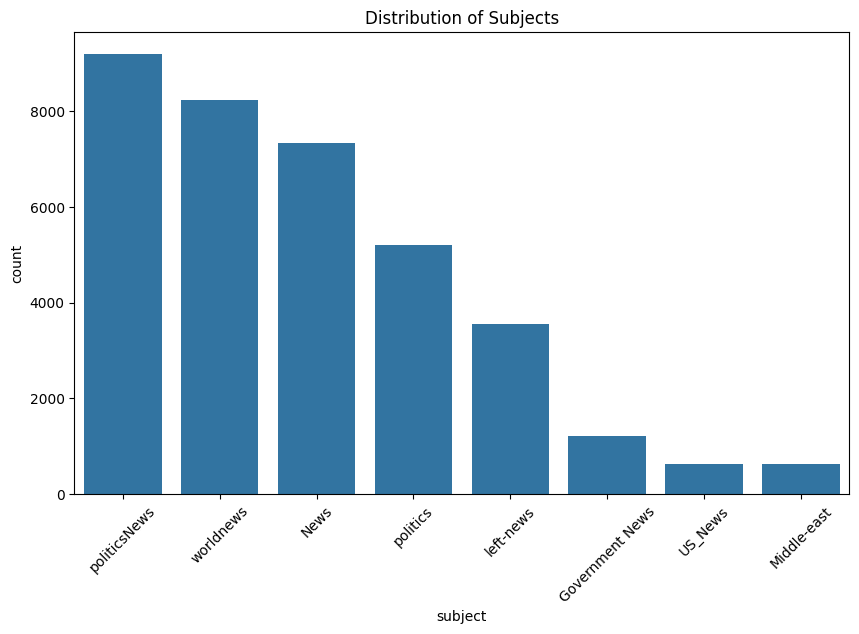

In [5]:
# Combine train and validation data for EDA
df_combined = pd.concat([df_train, df_valid], ignore_index=True)

# Check for quantitative and qualitative features
print("\nData types:")
print(df_combined.dtypes)

# Check for data imbalance
print("\nClass distribution:")
print(df_combined['label'].value_counts(normalize=True))

# Check for type of subjects and plot distribution
print("\nUnique subjects:")
print(df_combined['subject'].value_counts(normalize=True))
plt.figure(figsize=(10, 6))
sns.countplot(data=df_combined, x='subject', order=df_combined['subject'].value_counts().index)
plt.title('Distribution of Subjects')
plt.xticks(rotation=45)
plt.show()

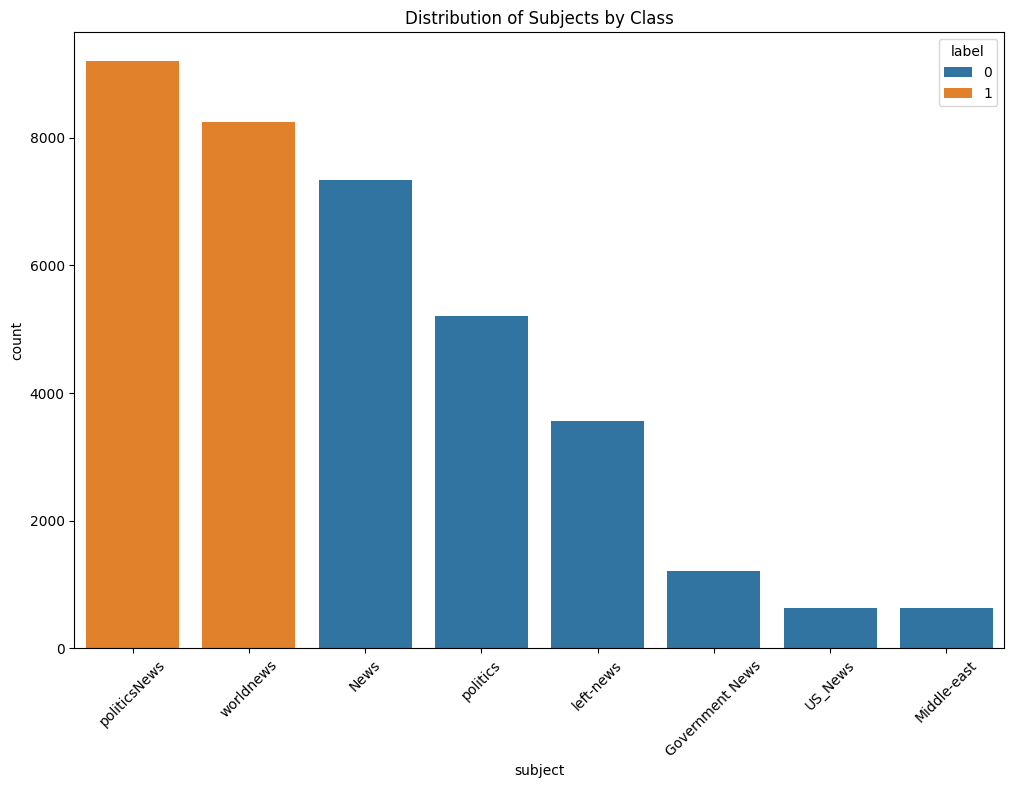

In [6]:
# Check for type of subjects within each class
plt.figure(figsize=(12, 8))
sns.countplot(data=df_combined, x='subject', hue='label', order=df_combined['subject'].value_counts().index)
plt.title('Distribution of Subjects by Class')
plt.xticks(rotation=45)
plt.show()


Date range: 2016-01-13 00:00:00 to 2017-12-31 00:00:00


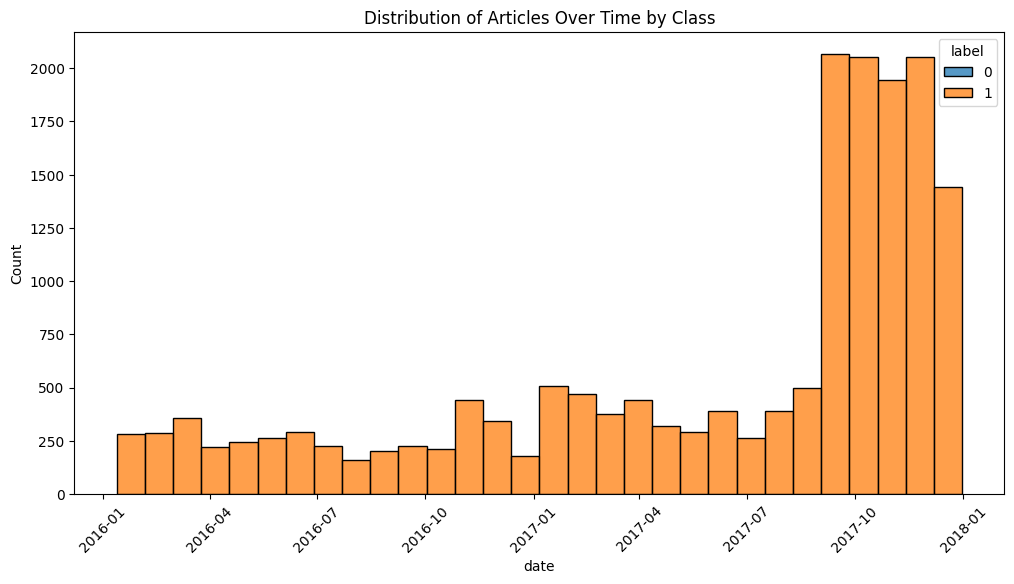

In [7]:
# Check for dates effect on classes and plot stack distribution
df_combined['date'] = pd.to_datetime(df_combined['date'], errors='coerce')
print("\nDate range:", df_combined['date'].min(), "to", df_combined['date'].max())
plt.figure(figsize=(12, 6))
sns.histplot(data=df_combined, x='date', hue='label', multiple='stack', bins=30)
plt.title('Distribution of Articles Over Time by Class')
plt.xticks(rotation=45)
plt.show()


Text length statistics:
count    36000.000000
mean        79.738278
std         25.295535
min          8.000000
25%         63.000000
50%         73.000000
75%         90.000000
max        279.000000
Name: text_length, dtype: float64


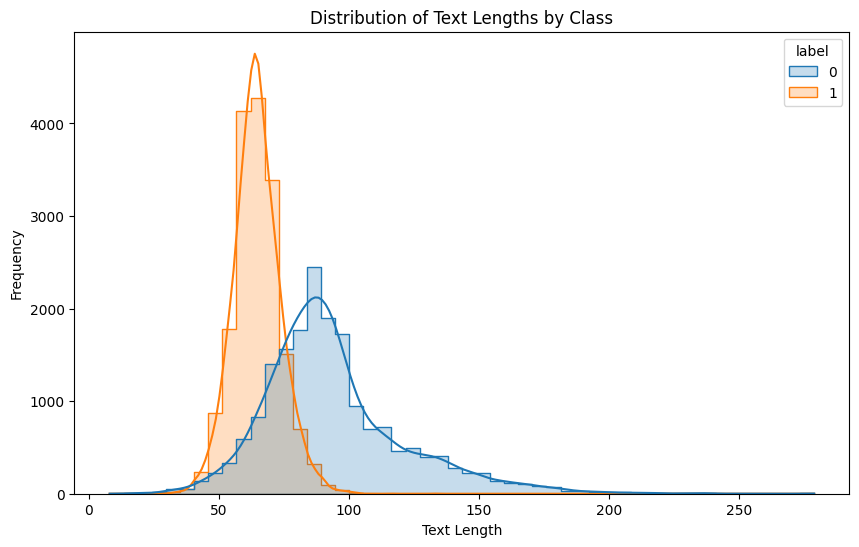

In [8]:
# Title length data analysis
df_combined['text_length'] = df_combined['title'].apply(len)
print("\nText length statistics:")
print(df_combined['text_length'].describe())

# Plot distribution of text lengths by class
plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='text_length', hue='label', bins=50, kde=True, element='step')
plt.title('Distribution of Text Lengths by Class')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

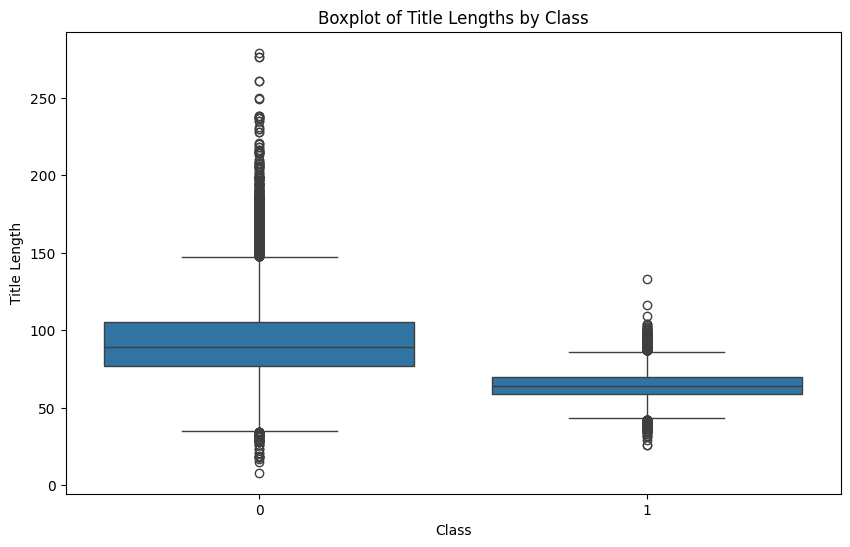

In [9]:
# Plot distribution of title lengths by class using boxplot
df_combined['title_length'] = df_combined['title'].apply(len)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='label', y='title_length')
plt.title('Boxplot of Title Lengths by Class')
plt.xlabel('Class')
plt.ylabel('Title Length')
plt.show()


Text length statistics:
count    36000.000000
mean      2482.520639
std       2168.900052
min          5.000000
25%       1278.000000
50%       2195.000000
75%       3105.000000
max      51793.000000
Name: text_length, dtype: float64


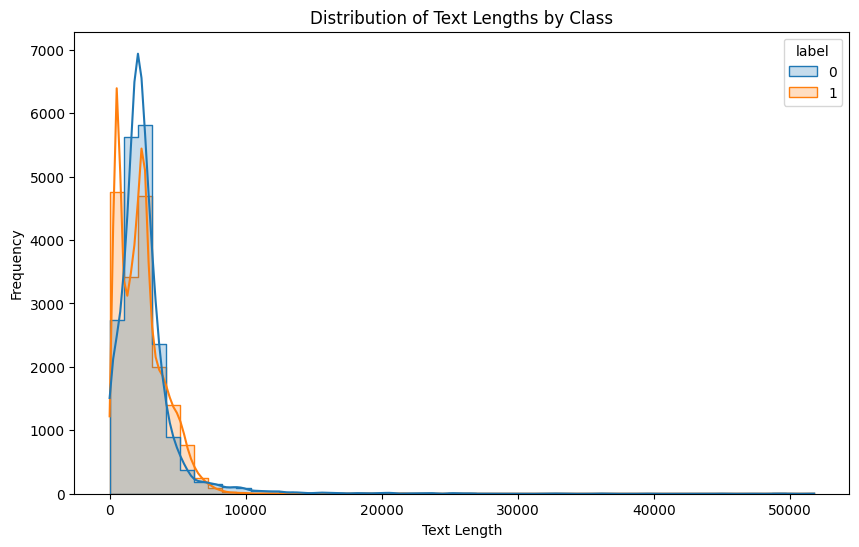

In [10]:
# Textual data analysis
df_combined['text_length'] = df_combined['text'].apply(len)
print("\nText length statistics:")
print(df_combined['text_length'].describe())

# Plot distribution of text lengths by class
plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='text_length', hue='label', bins=50, kde=True, element='step')
plt.title('Distribution of Text Lengths by Class')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Remove stopwords and punctuation, lemmatization
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def preprocess_text(text):
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    words = nltk.word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)
df_combined['cleaned_text'] = df_combined['text'].apply(preprocess_text)
df_combined['cleaned_title'] = df_combined['title'].apply(preprocess_text)
print("\nSample cleaned text:")
print(df_combined[['text', 'cleaned_text']].head())

In [20]:
# Khởi tạo stopwords và lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Tiền xử lý văn bản:
    - Chuyển về chữ thường
    - Loại bỏ ký tự đặc biệt & dấu câu (kể cả unicode như “ ’ …)
    - Tokenize (chia từ)
    - Loại bỏ stopwords
    - Lemmatization (đưa về gốc từ)
    """
    
    # 1️⃣ Chuyển tất cả về chữ thường
    text = text.lower()
    
    # 2️⃣ Loại bỏ ký tự đặc biệt unicode (ngoặc kép cong, dấu nháy cong, gạch ngang dài, vv.)
    text = re.sub(r'[’‘“”…–—]', '', text)
    
    # 3️⃣ Loại bỏ dấu câu thông thường (dựa vào string.punctuation)
    text = re.sub(f"[{re.escape(string.punctuation)}]", '', text)
    
    # 4️⃣ Tokenize thành từng từ
    words = nltk.word_tokenize(text)
    
    # 5️⃣ Loại bỏ stopwords và lemmatize từng từ
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    # 6️⃣ Ghép lại thành chuỗi
    return ' '.join(words)

# Áp dụng cho cột 'text' và 'title'
df_combined['cleaned_text'] = df_combined['text'].apply(preprocess_text)
df_combined['cleaned_title'] = df_combined['title'].apply(preprocess_text)

# In thử một số mẫu để kiểm tra
print("\nSample cleaned text:")
print(df_combined[['text', 'cleaned_text']].head())



Sample cleaned text:
                                                text  \
0  Former CIA director John Brennan on Friday cri...   
1  How did this man come to OWN this store? There...   
2  President Donald Trump on Thursday tapped Fede...   
3  Hillary Clinton ally David Brock is offering t...   
4  Pleading ignorance is a perfect ploy for Nancy...   

                                        cleaned_text  
0  former cia director john brennan friday critic...  
1  man come store information much fraudster exce...  
2  president donald trump thursday tapped federal...  
3  hillary clinton ally david brock offering pay ...  
4  pleading ignorance perfect ploy nancy pelosi b...  


In [21]:
# Analysis of common words in titles and texts
from collections import Counter
def get_most_common_words(text_series, n=20):
    all_words = ' '.join(text_series).lower().split()
    common_words = Counter(all_words).most_common(n)
    return common_words
print("\nMost common words in titles:")
print(get_most_common_words(df_combined['cleaned_text'].sort_index(ascending=True), n=20))


Most common words in titles:
[('said', 105530), ('trump', 103768), ('u', 51185), ('state', 47509), ('would', 44512), ('president', 42899), ('people', 33497), ('republican', 30729), ('one', 29749), ('year', 26989), ('also', 25181), ('new', 24273), ('government', 23016), ('clinton', 22852), ('donald', 22250), ('house', 22193), ('time', 21610), ('say', 20548), ('country', 20090), ('obama', 20027)]


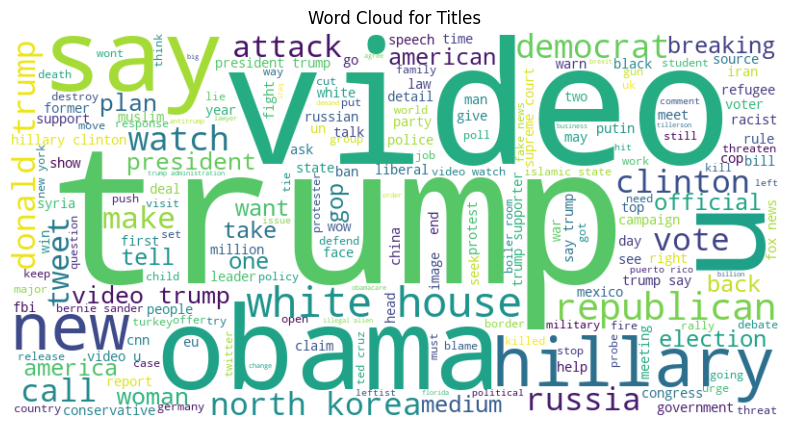

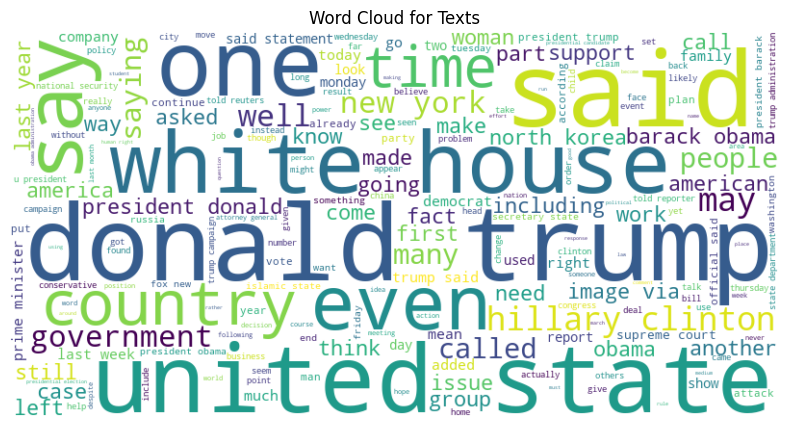

In [23]:
# draw word cloud for titles and texts
from wordcloud import WordCloud
def plot_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()
plot_wordcloud(' '.join(df_combined['cleaned_title']), 'Word Cloud for Titles')
plot_wordcloud(' '.join(df_combined['cleaned_text']), 'Word Cloud for Texts')

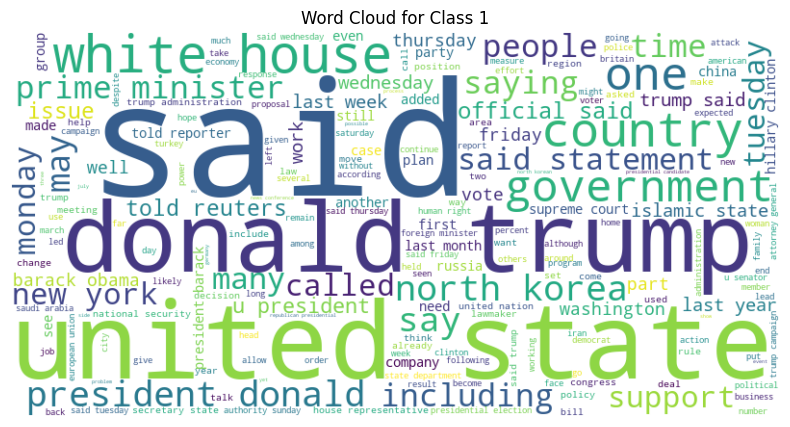

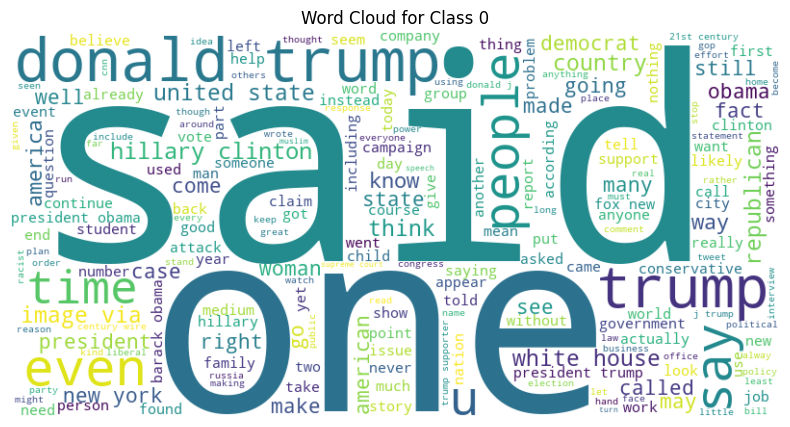

In [24]:
# Plot word cloud for each class
for label in df_combined['label'].unique():
    class_text = ' '.join(df_combined[df_combined['label'] == label]['cleaned_text'])
    plot_wordcloud(class_text, f'Word Cloud for Class {label}')
    

In [29]:
# Phân tích các cụm từ gồm 2 và 3 từ (Bi-grams, Tri-grams) phổ biến nhất trong từng lớp.
def get_ngrams(text_series, n=2, top_k=10):
    vectorizer = TfidfVectorizer(ngram_range=(n, n), stop_words='english')
    X = vectorizer.fit_transform(text_series)
    sum_words = X.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]
for label in df_combined['label'].unique():
    class_texts = df_combined[df_combined['label'] == label]['cleaned_text']
    # bigrams = get_ngrams(class_texts, n=2, top_k=10)
    trigrams = get_ngrams(class_texts, n=3, top_k=10)
    print(f"\nTop 10 Bi-grams for Class {label}:")
    # for gram, freq in bigrams:
    #     print(f"{gram}: {freq:.4f}")
    print(f"\nTop 10 Tri-grams for Class {label}:")
    for gram, freq in trigrams:
        print(f"{gram}: {freq:.4f}")



Top 10 Bi-grams for Class 1:

Top 10 Tri-grams for Class 1:
president donald trump: 95.2711
president barack obama: 41.0243
white house said: 36.3696
presidentelect donald trump: 26.5182
president vladimir putin: 24.7772
donald trump said: 22.0327
prime minister theresa: 21.5236
president barack obamas: 21.2747
russian president vladimir: 20.1167
secretary state rex: 19.9170

Top 10 Bi-grams for Class 0:

Top 10 Tri-grams for Class 0:
21st century wire: 44.4713
donald trump realdonaldtrump: 36.3854
black life matter: 31.1123
new york time: 27.8695
president donald trump: 23.9887
president united state: 22.2231
century wire say: 21.8421
president barack obama: 21.4281
news 21st century: 21.3933
video screen capture: 20.6223
